In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
from pydantic import BaseModel
from langgraph.types import interrupt, Command
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver
from typing import Literal
from langchain_groq import ChatGroq

c:\Users\hp\Desktop\Vector_1\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
llm = ChatGroq(model="openai/gpt-oss-20b")

In [5]:
class State(BaseModel):
    query:str = ""
    draft: str = ""
    human_feedback : str = ""
    final : str = ""
    revision_count: int = 0

In [6]:
def draft_email(state:State) -> State:
    prompt = f"Create a draft mail for {state.query}"
    if state.human_feedback:
        prompt = f"""Re-write this draft email about {state.query}.
                Previous Draft: {state.draft}
                Human Feedback to apply : {state.human_feedback}
        """

    response = llm.invoke([{"role":"user", "content": prompt}])
    state.draft = response.content
    state.human_feedback=""

    return state

In [24]:
def human_review_node(state:State):
    feedback = interrupt(
        {
            "draft_email": state.draft,
            "revision_count": state.revision_count,
            "question": "Reply 'approve' to finalize or describe changes to re-write the draft mail"
        }
    )

    fb= feedback.strip().lower()

    approved= False
    for word in ["approve","ok","yes","final"]:
        if word in fb:
            approved= True
            break

    if approved:
        state.human_feedback=""

    else:
        state.human_feedback= fb
        state.revision_count += 1

    return state

In [25]:
def send_mail_node(state:State):
    print("Email sent successfully")
    state.final = state.draft
    state.draft = ""
    state.human_feedback= ""
    state.revision_count=0
    return state

In [26]:
def router_after_feedback(state:State) -> Literal["draft","final"]:
    if state.human_feedback and state.revision_count <3:
        return "draft"
    return "final"

In [27]:
builder = StateGraph(State)
builder.add_node("draft", draft_email)
builder.add_node("human_review", human_review_node)
builder.add_node("final", send_mail_node)

builder.add_edge(START, "draft")
builder.add_edge("draft", "human_review")
builder.add_conditional_edges("human_review",router_after_feedback)
builder.add_edge("final",END)

graph= builder.compile(checkpointer= InMemorySaver())

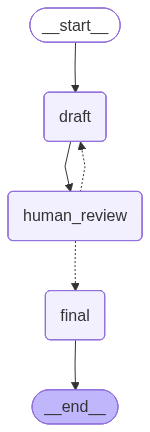

In [17]:
from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())

In [28]:
conf = {"configurable" : {"thread_id":1}}
response= graph.invoke(
    {
        "query": "I want to send leave request to my manager"
    },
    config=conf
)

In [29]:
print(response["draft"])

**Subject:** Leave Request – [Your Name] – [Dates]  

Dear [Manager’s Name],

I hope you’re doing well. I am writing to formally request a leave of absence from **[start date] to [end date]** (inclusive).  

**Reason for leave**  
I need to [briefly state reason – e.g., attend a family event, take a medical appointment, or simply recharge]. I have ensured that all my current tasks are up‑to‑date, and I have briefed [colleague’s name] on the status of ongoing projects. I will also be reachable by email for any urgent matters during my absence.

**Plan for coverage**  
- **Project A:** [Colleague] will monitor progress and handle any blockers.  
- **Daily stand‑ups:** I will send a summary of my work before I leave.  
- **Client communication:** I will provide [client name] with a brief note and introduce them to [colleague] for any immediate questions.

Please let me know if you need any additional information or if there are any concerns with the proposed dates. I’m happy to discuss th

In [30]:
response = graph.invoke(
    Command(
        resume="I want to replace Manager's name with Anurag Mohanty"
    ),
    config=conf
)

In [31]:
print(response["draft"])

**Subject:** Leave Request – [Your Name] – [Dates]

Dear Anurag Mohanty,

I hope you’re doing well. I am writing to formally request a leave of absence from **[start date] to [end date]** (inclusive).

**Reason for leave**  
I need to [briefly state reason – e.g., attend a family event, take a medical appointment, or simply recharge]. I have ensured that all my current tasks are up‑to‑date, and I have briefed [colleague’s name] on the status of ongoing projects. I will also be reachable by email for any urgent matters during my absence.

**Plan for coverage**  
- **Project A:** [Colleague] will monitor progress and handle any blockers.  
- **Daily stand‑ups:** I will send a summary of my work before I leave.  
- **Client communication:** I will provide [client name] with a brief note and introduce them to [colleague] for any immediate questions.

Please let me know if you need any additional information or if there are any concerns with the proposed dates. I’m happy to discuss this fur